# Análisis de Gestión de Inventario y Demanda — Equipo 6

**Samsung Innovation Campus Chile 2026 — Cohort 1 (Código y Programación)**

**Pregunta de análisis:** ¿Está el inventario calibrado frente a la demanda proyectada, y dónde y cuánto se desajusta entre riesgo de quiebre (falta de stock) y exceso de inventario?

Este notebook documenta el análisis que sustenta el dashboard. Cada sección explica **qué se hace y por qué**. El dataset es el *Retail Store Inventory Forecasting Dataset* (Kaggle), un dataset **sintético** con 73.100 filas, donde cada fila es un producto, en una tienda, en un día (2022-2024).

## 1. Carga de datos y revisión inicial

Cargamos el dataset y revisamos su tamaño, sus columnas y si tiene datos faltantes o duplicados. Esto determina cuánta limpieza necesita.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta relativa: el notebook vive en notebooks/ y los datos en ../data/
df = pd.read_csv("../data/retail_store_inventory.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Dimensiones:", df.shape)
print("Rango de fechas:", df["Date"].min().date(), "a", df["Date"].max().date())
df.head()

Dimensiones: (73100, 15)
Rango de fechas: 2022-01-01 a 2024-01-01


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [2]:
# Revisión de calidad: ¿hay nulos o duplicados?
print("Nulos por columna (total):", int(df.isnull().sum().sum()))
print("Filas duplicadas:", int(df.duplicated().sum()))

Nulos por columna (total): 0
Filas duplicadas: 0


**Observación:** el dataset no tiene valores nulos ni filas duplicadas. La limpieza necesaria es mínima: solo convertimos la fecha a tipo fecha (ya hecho). Por eso el análisis trabaja directamente sobre los datos originales.

## 2. Preparación: métricas de inventario

Creamos las métricas que permiten responder la pregunta. La clave es la **cobertura** = inventario ÷ demanda proyectada, que indica cuántas veces el inventario cubre la demanda:

- Cobertura **< 1** → la demanda supera al inventario → **riesgo de quiebre**.
- Cobertura **≈ 1** → equilibrio.
- Cobertura **> 2** → inventario holgado frente a la demanda.

También calculamos las unidades faltantes y las unidades por sobre la demanda.

In [3]:
# Cobertura (evitamos dividir por demanda cero o negativa)
demanda_segura = df["Demand Forecast"].where(df["Demand Forecast"] > 0)
df["Cobertura"] = df["Inventory Level"] / demanda_segura

# Unidades faltantes y unidades por sobre la demanda
df["Faltante"] = (df["Demand Forecast"] - df["Inventory Level"]).clip(lower=0)
df["Exceso"]   = (df["Inventory Level"] - df["Demand Forecast"]).clip(lower=0)

# Banderas de los dos tipos de desajuste
df["Riesgo"]     = df["Demand Forecast"] > df["Inventory Level"]
df["Sobrestock"] = df["Inventory Level"] > 2 * df["Demand Forecast"]

df[["Inventory Level", "Demand Forecast", "Cobertura", "Faltante", "Exceso", "Riesgo", "Sobrestock"]].head()

,Inventory Level,Demand Forecast,Cobertura,Faltante,Exceso,Riesgo,Sobrestock
0,231,135.47,1.705175,0.0,95.53,False,False
1,204,144.04,1.416273,0.0,59.96,False,False
2,102,74.02,1.378006,0.0,27.98,False,False
3,469,62.18,7.542618,0.0,406.82,False,True
4,166,9.26,17.926566,0.0,156.74,False,True


## 3. ¿Está el inventario calibrado a la demanda?

Resumimos la situación con la cobertura típica y el porcentaje de situaciones en cada extremo.

Usamos la **mediana** de la cobertura y no el promedio, porque la cobertura tiene valores extremos (cuando la demanda es casi cero, la cobertura se dispara a miles). En distribuciones así de sesgadas, la mediana representa mejor el caso típico; el promedio quedaría inflado por unos pocos casos raros.

In [4]:
print("Cobertura — media :", round(df["Cobertura"].mean(), 2), "(distorsionada por valores extremos)")
print("Cobertura — mediana:", round(df["Cobertura"].median(), 2), "(caso típico)")
print()
print("% en riesgo de quiebre (cobertura < 1):", round(100 * df["Riesgo"].mean(), 1), "%")
print("% con inventario holgado (cobertura > 2):", round(100 * df["Sobrestock"].mean(), 1), "%")

Cobertura — media : 6.69 (distorsionada por valores extremos)
Cobertura — mediana: 1.9 (caso típico)

% en riesgo de quiebre (cobertura < 1): 3.5 %
% con inventario holgado (cobertura > 2): 47.9 %


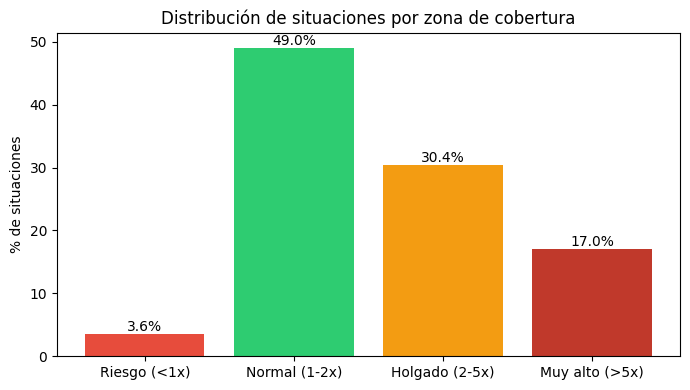

In [5]:
# Distribución por zonas de cobertura
orden = ["Riesgo (<1x)", "Normal (1-2x)", "Holgado (2-5x)", "Muy alto (>5x)"]
zonas = pd.cut(df["Cobertura"], bins=[-np.inf, 1, 2, 5, np.inf], labels=orden)
zona_pct = zonas.value_counts(normalize=True).reindex(orden) * 100

plt.figure(figsize=(7, 4))
plt.bar(orden, zona_pct.values, color=["#e74c3c", "#2ecc71", "#f39c12", "#c0392b"])
plt.ylabel("% de situaciones")
plt.title("Distribución de situaciones por zona de cobertura")
for i, v in enumerate(zona_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

Para hacer tangible el desajuste, comparamos el total de unidades por sobre la demanda contra el total de unidades faltantes en todo el período.

In [6]:
total_exceso = df["Exceso"].sum()
total_faltante = df["Faltante"].sum()
print(f"Unidades por sobre la demanda proyectada (acumulado): {total_exceso:,.0f}")
print(f"Unidades faltantes por quiebre (acumulado):           {total_faltante:,.0f}")
print(f"Razón: por cada unidad que faltó, hubo {total_exceso/total_faltante:,.0f} por sobre la demanda")

Unidades por sobre la demanda proyectada (acumulado): 9,737,778
Unidades faltantes por quiebre (acumulado):           17,294
Razón: por cada unidad que faltó, hubo 563 por sobre la demanda


**Hallazgo:** el inventario casi siempre supera a la demanda (cobertura mediana ~1,9x). El riesgo de quiebre es marginal (~3,5%), mientras que casi la mitad de las situaciones mantiene inventario holgado. El desajuste es abrumadoramente por exceso, no por falta.

## 4. ¿La reposición responde a la necesidad?

Si la reposición fuera inteligente, se ordenarían **más** unidades cuando falta stock y **menos** cuando sobra. Comparamos las unidades ordenadas promedio en ambas situaciones.

Unidades ordenadas promedio cuando FALTA stock (riesgo): 110.5
Unidades ordenadas promedio cuando SOBRA stock (holgado): 110.2
Correlación entre lo ordenado y la brecha (demanda - inventario): -0.002


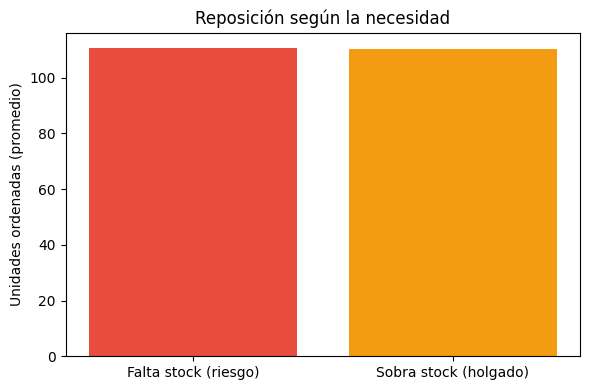

In [7]:
ordenado_riesgo = df.loc[df["Riesgo"], "Units Ordered"].mean()
ordenado_exceso = df.loc[df["Sobrestock"], "Units Ordered"].mean()
print(f"Unidades ordenadas promedio cuando FALTA stock (riesgo): {ordenado_riesgo:.1f}")
print(f"Unidades ordenadas promedio cuando SOBRA stock (holgado): {ordenado_exceso:.1f}")
print(f"Correlación entre lo ordenado y la brecha (demanda - inventario): {df['Units Ordered'].corr(df['Demand Forecast'] - df['Inventory Level']):.3f}")

plt.figure(figsize=(6, 4))
plt.bar(["Falta stock (riesgo)", "Sobra stock (holgado)"], [ordenado_riesgo, ordenado_exceso],
        color=["#e74c3c", "#f39c12"])
plt.ylabel("Unidades ordenadas (promedio)")
plt.title("Reposición según la necesidad")
plt.tight_layout()
plt.show()

**Hallazgo:** se ordena prácticamente la misma cantidad tanto cuando falta como cuando sobra stock, y la correlación con la necesidad es nula. La reposición **no responde a la necesidad** de inventario.

## 5. ¿Algún factor comercial explica las ventas?

Antes de centrarnos en el inventario, verificamos si alguna palanca comercial (precio, descuento, competencia, promociones) mueve las ventas, y si la demanda proyectada acompaña a las ventas reales.

In [8]:
print("Correlación de cada factor con las ventas (Units Sold):")
for col in ["Price", "Discount", "Competitor Pricing"]:
    print(f"  {col:20s}: {df['Units Sold'].corr(df[col]):+.3f}")

# Efecto de promociones/feriados
con = df[df["Holiday/Promotion"] == 1]["Units Sold"].mean()
sin = df[df["Holiday/Promotion"] == 0]["Units Sold"].mean()
print(f"\nVentas promedio con promoción/feriado: {con:.1f}")
print(f"Ventas promedio sin promoción/feriado: {sin:.1f}")
print(f"Uplift de promoción: {100*(con-sin)/sin:+.1f}%")

print(f"\nCorrelación demanda proyectada vs ventas reales: {df['Units Sold'].corr(df['Demand Forecast']):.3f}")

Correlación de cada factor con las ventas (Units Sold):
  Price               : +0.001
  Discount            : +0.003
  Competitor Pricing  : +0.001

Ventas promedio con promoción/feriado: 136.4
Ventas promedio sin promoción/feriado: 136.5
Uplift de promoción: -0.1%

Correlación demanda proyectada vs ventas reales: 0.997


**Hallazgo:** ningún factor comercial muestra relación con las ventas (correlaciones ≈ 0) y las promociones no tienen efecto medible. En cambio, la demanda proyectada sigue casi perfectamente a las ventas reales (correlación ≈ 0,99). Por eso el problema no está en el pronóstico, sino en cómo se gestiona el inventario frente a esa demanda.

## 6. Ranking de riesgo con el módulo del equipo (`inventory_risk.py`)

Usamos el módulo desarrollado por el equipo, que calcula un `risk_score`, lo clasifica (Bajo/Medio/Alto) y genera alertas. Lo aplicamos a los datos y mostramos las situaciones más críticas.

In [9]:
import sys
sys.path.append("..")  # para importar inventory_risk.py desde la carpeta del proyecto
from inventory_risk import calcular_riesgo_inventario

df_riesgo = calcular_riesgo_inventario(df)
print("Distribución de categorías de riesgo:")
print(df_riesgo["risk_category"].value_counts())

# Las 10 situaciones más críticas según el módulo
df_riesgo[["Store ID", "Product ID", "Category", "Inventory Level",
           "Demand Forecast", "risk_score", "risk_category"]].head(10)

Distribución de categorías de riesgo:
risk_category
Bajo     49515
Medio    21000
Alto      2585
Name: count, dtype: int64


,Store ID,Product ID,Category,Inventory Level,Demand Forecast,risk_score,risk_category
0,S001,P0005,Clothing,51,69.89,1.370392,Alto
1,S001,P0008,Groceries,50,67.20,1.344000,Alto
2,S002,P0012,Clothing,59,78.97,1.338475,Alto
3,S003,P0019,Electronics,53,70.49,1.330000,Alto
4,S004,P0009,Clothing,50,65.80,1.316000,Alto
5,S005,P0019,Toys,53,69.56,1.312453,Alto
6,S002,P0020,Clothing,64,83.95,1.311719,Alto
7,S003,P0008,Clothing,61,79.64,1.305574,Alto
8,S005,P0018,Toys,58,75.32,1.298621,Alto
9,S005,P0010,Toys,56,71.97,1.285179,Alto


## 7. Conclusiones y limitaciones

**Conclusiones**

1. El inventario casi siempre supera a la demanda proyectada (cobertura mediana ~1,9x). El riesgo de quiebre es marginal (~3,5%); casi la mitad de las situaciones mantiene inventario holgado.
2. El desajuste es por **exceso**, no por falta: las unidades por sobre la demanda superan ampliamente a las faltantes.
3. La **reposición no responde a la necesidad**: se ordena casi lo mismo cuando falta que cuando sobra stock.
4. **Ningún factor comercial mueve las ventas** y el pronóstico ya acompaña casi perfectamente a las ventas reales, por lo que el problema está en la **calibración del inventario**, no en el pronóstico.

**Limitaciones**

- El dataset es **sintético**, por lo que ninguna variable comercial explica las ventas; no es posible hacer recomendaciones de pricing ni de marketing.
- Las columnas `Region` y `Seasonality` se comportan como etiquetas casi aleatorias, por lo que no se usan como hallazgo.
- Es un análisis **retrospectivo** (diagnóstico) sobre datos históricos; la misma lógica, aplicada a datos actuales, serviría para monitoreo en tiempo real.